Student Performance - Classification

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

SEED = 42

In [4]:
df = pd.read_csv('student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df['passed'] = (df['G3'] >= 10).astype(int)

X_clf = df.drop(['G1', 'G2', 'G3', 'passed'], axis=1)
y_clf = df['passed']

X_clf = pd.get_dummies(X_clf, drop_first=True)
y_clf.value_counts()

passed
1    265
0    130
Name: count, dtype: int64

In [6]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

In [7]:
siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train),
    "Logistic": LogisticRegression(max_iter=1000).fit(Xc_train, yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train, yc_train),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED).fit(Xc_train, yc_train),
    "Rastgele orman": RandomForestClassifier(random_state=SEED).fit(Xc_train, yc_train)
}

satirlar = []
for ad, m in siniflandiricilar.items():
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test))
    })

sonuc = pd.DataFrame(satirlar).set_index("Model").round(3)
sonuc

,Eğitim,Test
Model,,
Baseline,0.671,0.671
Logistic,0.766,0.658
KNN,0.797,0.646
Karar ağacı,1.000,0.658
Rastgele orman,1.000,0.684


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_satirlar = []

for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    cv_satirlar.append({
        "Model": ad, 
        "Ortalama skor": skorlar.mean(), 
        "Standart sapma": skorlar.std()
    })

cv_sonuc = pd.DataFrame(cv_satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
cv_sonuc

,Ortalama skor,Standart sapma
Model,,
KNN,0.706,0.036
Rastgele orman,0.690,0.045
Logistic,0.687,0.033
Baseline,0.671,0.006
Karar ağacı,0.652,0.065


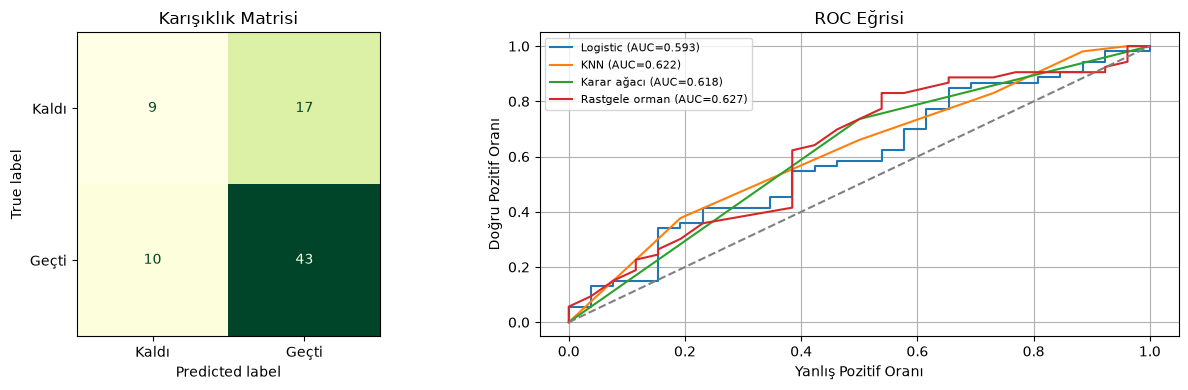

In [9]:
model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin, display_labels=["Kaldı", "Geçti"], cmap="YlGn", ax=axes[0], colorbar=False
)
axes[0].set_title("Karışıklık Matrisi")
axes[0].grid(False)

for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} (AUC={roc_auc_score(yc_test, p):.3f})")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış Pozitif Oranı")
axes[1].set_ylabel("Doğru Pozitif Oranı")
axes[1].set_title("ROC Eğrisi")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()